# 2 · Feature Engineering & Evaluation

Systematic feature engineering for German electricity demand forecasting (TFT model).
Starting from 9 raw features with a seasonal naive MAE of ~3,600 MW, this notebook
progresses through cyclical encodings, demand lags, interactions, and a full
comparison against the legacy complete_data feature set (leakage fixed).

**Final feature set: see Section 11.**

| Stage | Features | MAE (MW) | Bias (MW) |
|---|---|---|---|
| Seasonal naive | — | 3,593 | 0 |
| Raw baseline | 9 | 6,627 | +1,454 |
| Engineered | 12 | 4,592 | +1,502 |
| + Lags | 18 | 2,314 | +25 |
| + Interactions | 24 | 2,124 | +52 |
| Complete Data fixed | 56 | 1,976 | +45 |
| **Final (de-redundified)** | **TBC** | **TBC** | **TBC** |

The remaining error in linear models is structural — non-linear hour×season×weekday
interactions that Ridge cannot fit. The TFT's variable selection and temporal
attention mechanism handle these directly from the encoder sequence.


---
## 1 · Setup & Data Load

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
load_dotenv(os.path.join(PROJECT_ROOT, '.env'))

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', 80)

In [2]:
demand = pd.read_sql(text("""
    SELECT date_time AS timestamp,
           \"actual_demand(MW)\" AS actual_demand
    FROM energy_demand ORDER BY date_time
"""), engine)
demand['timestamp'] = pd.to_datetime(demand['timestamp'], utc=True).dt.tz_localize(None)

weather = pd.read_sql(text("""
    SELECT date_time AS timestamp,
           \"temperature_2m(°C)\"      AS temperature,
           \"relative_humidity_2m(%)\" AS humidity,
           \"rain(mm)\"               AS rain,
           \"snow_depth(m)\"          AS snow_depth,
           \"snowfall(cm)\"           AS snowfall
    FROM weather ORDER BY date_time
"""), engine)
weather['timestamp'] = pd.to_datetime(weather['timestamp'], utc=True).dt.tz_localize(None)

holidays = pd.read_sql(text("""
    SELECT date, is_public_holiday FROM holidays WHERE is_public_holiday = true
"""), engine)
holidays['date'] = pd.to_datetime(holidays['date'])

df = demand.merge(weather, on='timestamp', how='inner').sort_values('timestamp').reset_index(drop=True)
df['date'] = df['timestamp'].dt.date.astype('datetime64[ns]')
df['is_public_holiday'] = df['date'].isin(holidays['date']).astype(int)
df.drop(columns=['date'], inplace=True)

# Base temporal columns used throughout
df['hour']  = df['timestamp'].dt.hour
df['dow']   = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

print(f'Loaded {len(df):,} hourly records')
print(f'Date range: {df["timestamp"].min()} → {df["timestamp"].max()}')

Loaded 62,145 hourly records
Date range: 2019-01-01 00:00:00 → 2026-02-02 15:00:00


---
## 2 · Cyclical Encodings

Linear `hour` (0–23) has two problems:
1. The boundary is artificial — hour 23 and hour 0 are 1 hour apart but 23 units apart numerically
2. The relationship with demand is non-monotonic (U-shaped across the day), so Pearson r ≈ 0.30 even though hour is the primary driver

Encoding each cycle as a sin/cos pair maps the values onto a unit circle, preserving continuity at boundaries and giving the model two orthogonal components that together describe position in the cycle. The same applies to day-of-week (Mon wraps to Sun) and month (Dec wraps to Jan).

**Season** is added as an explicit cyclical feature — a 4-point cycle (spring/summer/autumn/winter) that gives a smoother seasonal signal than the binary DST flags and sits between monthly granularity and a fully continuous month encoding.

In [3]:
# ── Cyclical encodings ───────────────────────────────────────────────────────
df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['dow_sin']   = np.sin(2 * np.pi * df['dow']   / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['dow']   / 7)
df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
df['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / 12)
print('Cyclical features added: hour_sin/cos  dow_sin/cos  month_sin/cos')


Cyclical features added: hour_sin/cos  dow_sin/cos  month_sin/cos


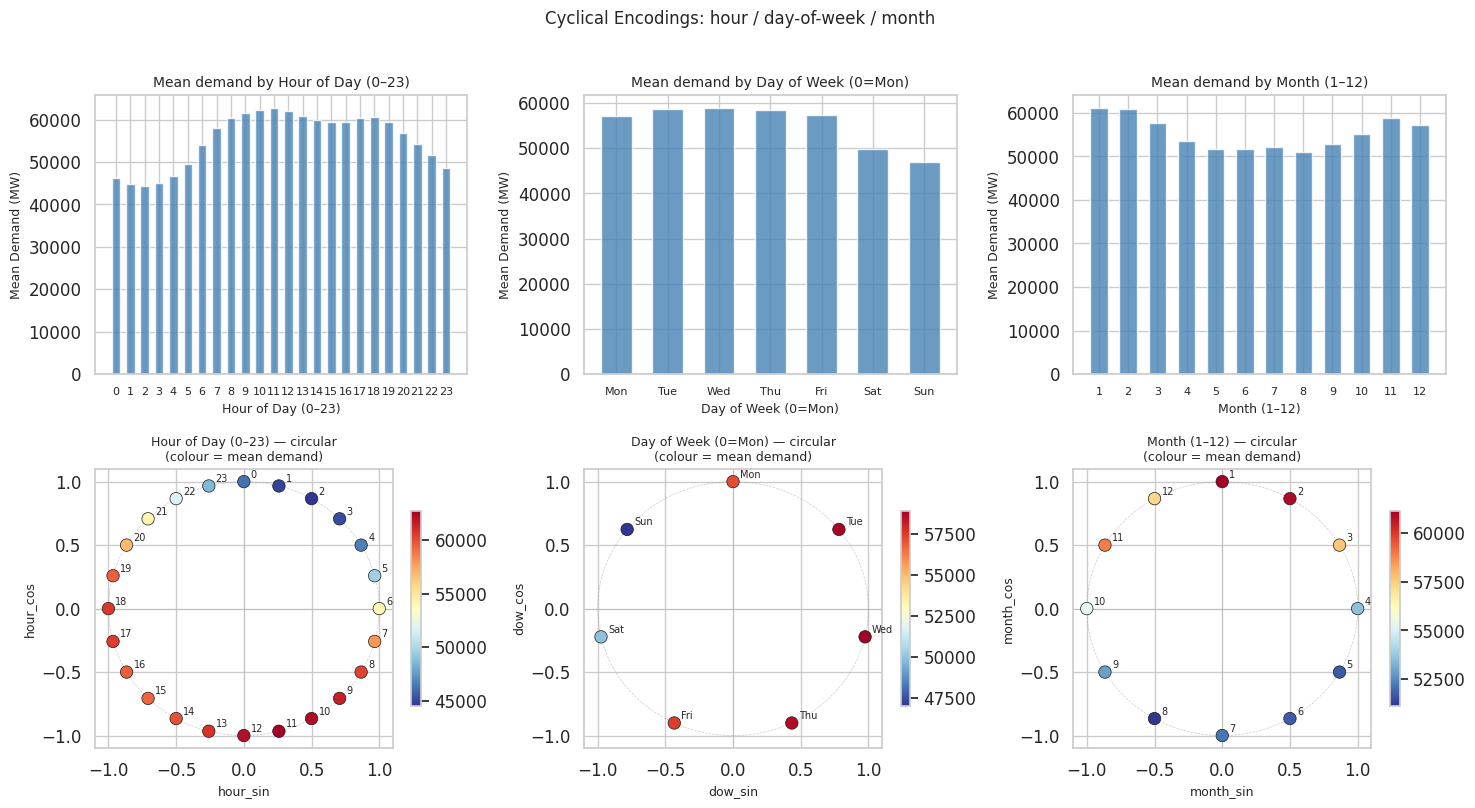

In [ ]:
# ── Visualise cyclical encodings ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

configs = [
    ('hour',  'hour_sin',  'hour_cos',  24, 'Hour of Day (0–23)'),
    ('dow',   'dow_sin',   'dow_cos',   7,  'Day of Week (0=Mon)'),
    ('month', 'month_sin', 'month_cos', 12, 'Month (1–12)'),
]
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

for col, (raw, sname, cname, period, xlabel) in enumerate(configs):
    ax_bar   = axes[0][col]
    ax_polar = axes[1][col]

    mean_demand = df.groupby(raw)['actual_demand'].mean()
    ax_bar.bar(mean_demand.index, mean_demand.values, color='steelblue', alpha=0.8, width=0.6)
    ax_bar.set_xlabel(xlabel, fontsize=9)
    ax_bar.set_ylabel('Mean Demand (MW)', fontsize=9)
    ax_bar.set_title(f'Mean demand by {xlabel}', fontsize=10)
    ax_bar.set_xticks(sorted(mean_demand.index.tolist()))
    if raw == 'dow':
        ax_bar.set_xticklabels(dow_labels, fontsize=8)
    else:
        ax_bar.set_xticklabels(sorted(mean_demand.index.tolist()), fontsize=8)

    mean_sc = df.groupby(raw)[['actual_demand', sname, cname]].mean()
    sc = ax_polar.scatter(mean_sc[sname], mean_sc[cname],
                          c=mean_sc['actual_demand'], cmap='RdYlBu_r',
                          s=80, zorder=3, edgecolors='k', linewidths=0.5)
    for idx_val, row in mean_sc.iterrows():
        label = dow_labels[int(idx_val)] if raw == 'dow' else str(idx_val)  # type: ignore[arg-type]
        ax_polar.annotate(label, (row[sname], row[cname]),
                          textcoords='offset points', xytext=(5, 3), fontsize=7)

    theta = np.linspace(0, 2 * np.pi, 200)
    ax_polar.plot(np.sin(theta), np.cos(theta), 'grey', lw=0.5, ls='--', alpha=0.4)
    ax_polar.axhline(0, color='grey', lw=0.4, alpha=0.3)
    ax_polar.axvline(0, color='grey', lw=0.4, alpha=0.3)
    ax_polar.set_xlabel(sname, fontsize=9)
    ax_polar.set_ylabel(cname, fontsize=9)
    ax_polar.set_title(f'{xlabel} — circular\n(colour = mean demand)', fontsize=9)
    plt.colorbar(sc, ax=ax_polar, shrink=0.7)

plt.suptitle('Cyclical Encodings: hour / day-of-week / month', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 3 · Temperature Features

Raw temperature vs demand had Pearson r = −0.16 — very weak linear signal. The scatter in notebook 01 suggested a U-shape: demand rises both as it gets cold (heating load) and at high temperatures (cooling/air conditioning). However the cooling signal in Germany is much weaker than heating, so the dominant effect is the cold side.

`heating_demand = max(0, 18 − temperature)` is a standard heating degree-day metric. 18 °C is the conventional balance point below which space heating activates. This converts the non-monotonic relationship into a monotonic one. Values above 18 °C correctly map to 0 — the cluster at zero in the scatter is real data, not a bug: it represents every warm hour in the dataset.

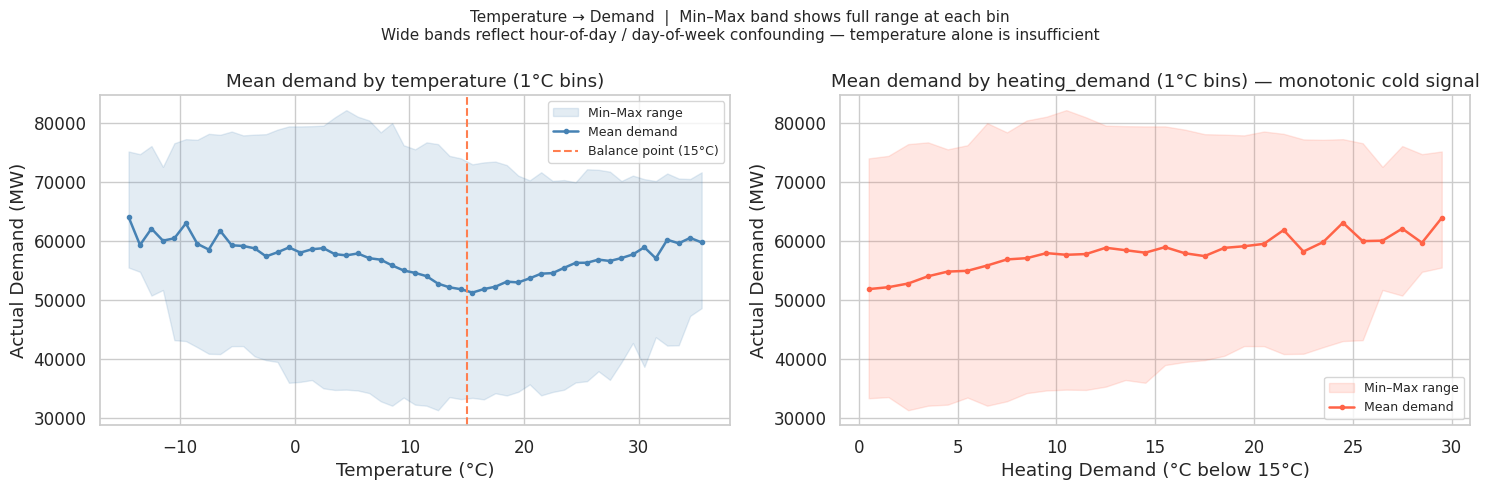

Pearson r — temperature:     -0.164
Pearson r — heating_demand:  0.216  (+0.053 in |r|)

Note: the 20–40k MW range at a single temperature bin is real.
It is explained by hour-of-day and day-of-week confounding — a weekday
noon in January and a Sunday 3am in January can share the same temperature.
This confirms temperature must be used *in combination* with temporal features.


In [ ]:
# ── Temperature → demand: find empirical balance point ──────────────────────
# Use 1°C integer bins so axvline lands on a real bin boundary
BALANCE_POINT = 15  # °C  (EDA trough sits between 14–16; 15 is the midpoint)

df['heating_demand']     = np.maximum(BALANCE_POINT - df['temperature'], 0)
df['heating_demand_sq']  = df['heating_demand'] ** 2
df['heating_demand_log'] = np.log1p(df['heating_demand'])

# Bin at integer °C boundaries so the balance-point line aligns with a bin edge
temp_bins  = list(range(-16, 37))          # -16, -15, ..., 36
df['temp_bin'] = pd.cut(df['temperature'], bins=temp_bins)
temp_stats = df.groupby('temp_bin', observed=True)['actual_demand'].agg(
    ['mean', 'min', 'max']).dropna()
temp_mid = [float(iv.mid) for iv in temp_stats.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].fill_between(temp_mid, temp_stats['min'], temp_stats['max'],
                     alpha=0.15, color='steelblue', label='Min–Max range')
axes[0].plot(temp_mid, temp_stats['mean'], 'o-', color='steelblue',
             ms=3, lw=1.8, label='Mean demand')
axes[0].axvline(BALANCE_POINT, color='coral', ls='--', lw=1.5,
                label=f'Balance point ({BALANCE_POINT}°C)')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Actual Demand (MW)')
axes[0].set_title('Mean demand by temperature (1°C bins)')
axes[0].legend(fontsize=9)

# Heating demand bins — same granularity
hd_bins = list(range(0, 33))
df['hd_bin'] = pd.cut(df['heating_demand'], bins=hd_bins)
hd_stats = df.groupby('hd_bin', observed=True)['actual_demand'].agg(
    ['mean', 'min', 'max']).dropna()
hd_mid = [float(iv.mid) for iv in hd_stats.index]

axes[1].fill_between(hd_mid, hd_stats['min'], hd_stats['max'],
                     alpha=0.15, color='tomato', label='Min–Max range')
axes[1].plot(hd_mid, hd_stats['mean'], 'o-', color='tomato',
             ms=3, lw=1.8, label='Mean demand')
axes[1].set_xlabel(f'Heating Demand (°C below {BALANCE_POINT}°C)')
axes[1].set_ylabel('Actual Demand (MW)')
axes[1].set_title('Mean demand by heating_demand (1°C bins) — monotonic cold signal')
axes[1].legend(fontsize=9)

df.drop(columns=['temp_bin', 'hd_bin'], inplace=True)

plt.suptitle(
    'Temperature → Demand  |  Min–Max band shows full range at each bin\n'
    'Wide bands reflect hour-of-day / day-of-week confounding — temperature alone is insufficient',
    fontsize=11)
plt.tight_layout()
plt.show()

r_temp    = float(df[['temperature',    'actual_demand']].corr().iloc[0, 1])  # type: ignore[arg-type]
r_heating = float(df[['heating_demand', 'actual_demand']].corr().iloc[0, 1])  # type: ignore[arg-type]
print(f'Pearson r — temperature:     {r_temp:.3f}')
print(f'Pearson r — heating_demand:  {r_heating:.3f}  ({abs(r_heating)-abs(r_temp):+.3f} in |r|)')
print()
print('Note: the 20–40k MW range at a single temperature bin is real.')
print('It is explained by hour-of-day and day-of-week confounding — a weekday')
print('noon in January and a Sunday 3am in January can share the same temperature.')
print('This confirms temperature must be used *in combination* with temporal features.')

---
## 4 · Pearson r & Mutual Information

Pearson r measures linear correlation only. Mutual Information (MI) measures any statistical dependency — linear or not. Comparing the two reveals which features have signal that Pearson misses (like `hour` with its non-monotonic curve).

MI values are normalised to [0, 1] within each set for comparison.

In [ ]:
# ── Baseline (pre-engineering) vs Engineered feature MI/Pearson comparison ───
BASELINE_FEATURES = [
    'hour', 'dow', 'month',
    'is_public_holiday',
    'temperature', 'humidity', 'rain', 'snow_depth', 'snowfall',
]

ENG_FEATURES = [
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'is_public_holiday',
    'heating_demand',
    'humidity', 'rain', 'snow_depth', 'snowfall',
]

all_cols = list(dict.fromkeys(BASELINE_FEATURES + ENG_FEATURES + ['actual_demand']))
eval_df  = df[all_cols].dropna().reset_index(drop=True)
y        = eval_df['actual_demand'].to_numpy()

pearson_raw = np.array([float(eval_df[f].corr(eval_df['actual_demand'])) for f in BASELINE_FEATURES])
pearson_eng = np.array([float(eval_df[f].corr(eval_df['actual_demand'])) for f in ENG_FEATURES])

discrete_raw = [i for i, f in enumerate(BASELINE_FEATURES) if f == 'is_public_holiday']
discrete_eng = [i for i, f in enumerate(ENG_FEATURES)      if f == 'is_public_holiday']

mi_raw = mutual_info_regression(eval_df[BASELINE_FEATURES].to_numpy(), y,
                                discrete_features=discrete_raw, n_neighbors=10, random_state=42)
mi_eng = mutual_info_regression(eval_df[ENG_FEATURES].to_numpy(),      y,
                                discrete_features=discrete_eng, n_neighbors=10, random_state=42)

results_raw = pd.DataFrame({'pearson_r': pearson_raw, 'abs_r': np.abs(pearson_raw),
                             'mi_norm':  mi_raw / mi_raw.max()}, index=BASELINE_FEATURES
                           ).sort_values('mi_norm', ascending=False)
results_eng = pd.DataFrame({'pearson_r': pearson_eng, 'abs_r': np.abs(pearson_eng),
                             'mi_norm':  mi_eng / mi_eng.max()}, index=ENG_FEATURES
                           ).sort_values('mi_norm', ascending=False)

print('Baseline features (pre-engineering):')
display(results_raw.round(3))
print('\nEngineered features (Baseline):')
display(results_eng.round(3))

Baseline features (pre-engineering):


,pearson_r,abs_r,mi_norm
hour,0.301,0.301,1.000
dow,-0.362,0.362,0.472
month,-0.109,0.109,0.388
temperature,-0.164,0.164,0.284
humidity,-0.094,0.094,0.107
snow_depth,0.160,0.160,0.079
is_public_holiday,-0.164,0.164,0.049
snowfall,0.049,0.049,0.010
rain,0.013,0.013,0.009



Engineered features (Baseline):


,pearson_r,abs_r,mi_norm
hour_cos,-0.563,0.563,1.000
dow_sin,0.380,0.380,0.680
month_cos,0.343,0.343,0.513
hour_sin,-0.206,0.206,0.365
heating_demand,0.216,0.216,0.337
humidity,-0.094,0.094,0.154
dow_cos,-0.115,0.115,0.153
snow_depth,0.160,0.160,0.113
month_sin,-0.020,0.020,0.095
is_public_holiday,-0.164,0.164,0.071


---
## 5 · Engineered Feature Intercorrelation

Do the engineered features introduce redundancy with each other? We check pairwise correlation and flag pairs above |r| > 0.7.

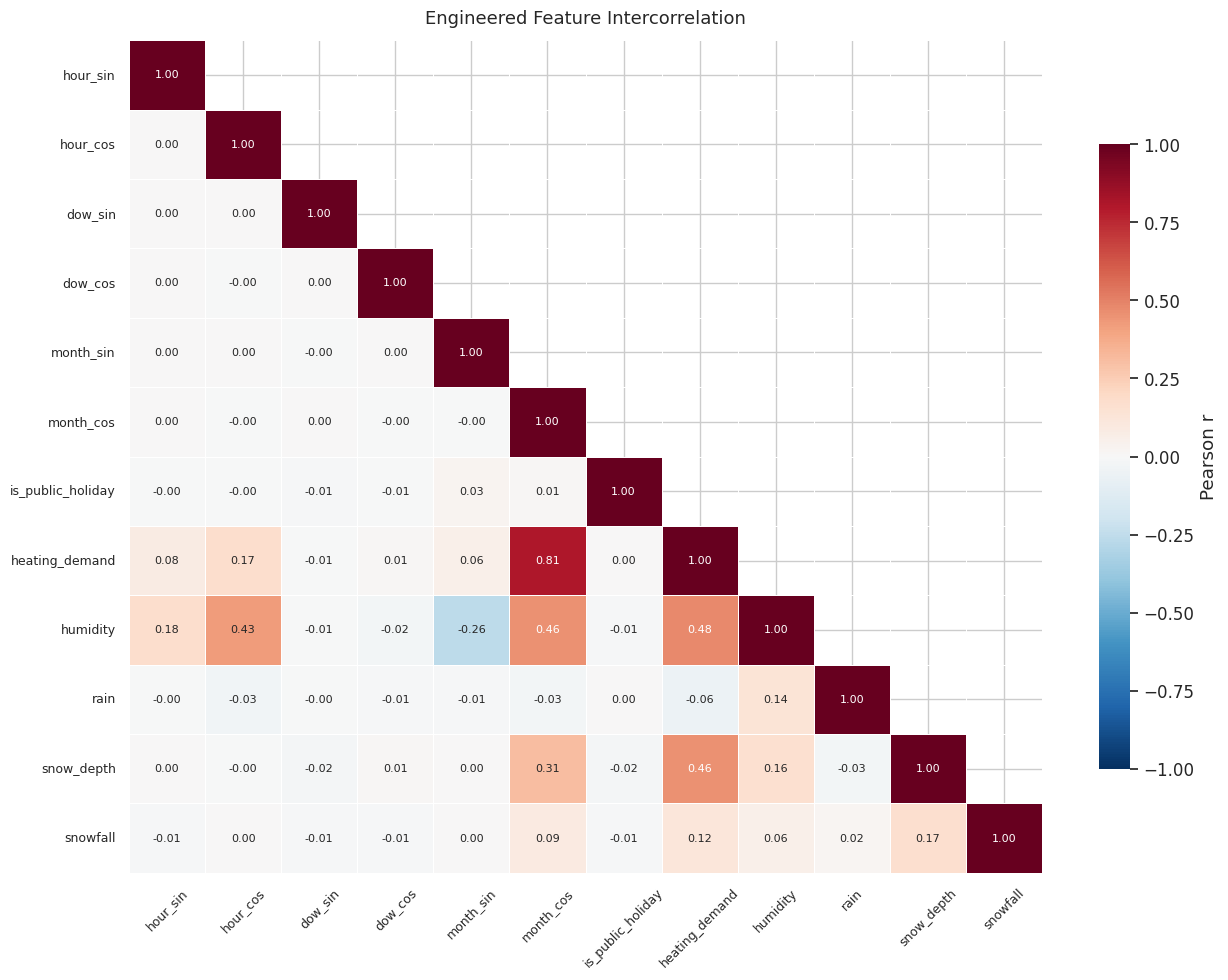

Highly correlated feature pairs (|r| > 0.7):
  month_cos                      × heating_demand                  r = 0.809


In [ ]:
# ── Engineered feature pairwise correlation ───────────────────────────────────
eng_corr = eval_df[ENG_FEATURES].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(eng_corr, dtype=bool), k=1)
sns.heatmap(
    eng_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'}
)
ax.set_title('Engineered Feature Intercorrelation', fontsize=13, pad=12)
ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.show()

# Flag any pairs with |r| > 0.7 (strong multicollinearity)
print('Highly correlated feature pairs (|r| > 0.7):')
found = False
for i in range(len(ENG_FEATURES)):
    for j in range(i+1, len(ENG_FEATURES)):
        r = float(eng_corr.iloc[i, j])  # type: ignore[arg-type]
        if abs(r) > 0.7:
            print(f'  {ENG_FEATURES[i]:30s} × {ENG_FEATURES[j]:30s}  r = {r:.3f}')
            found = True
if not found:
    print('  None above threshold.')

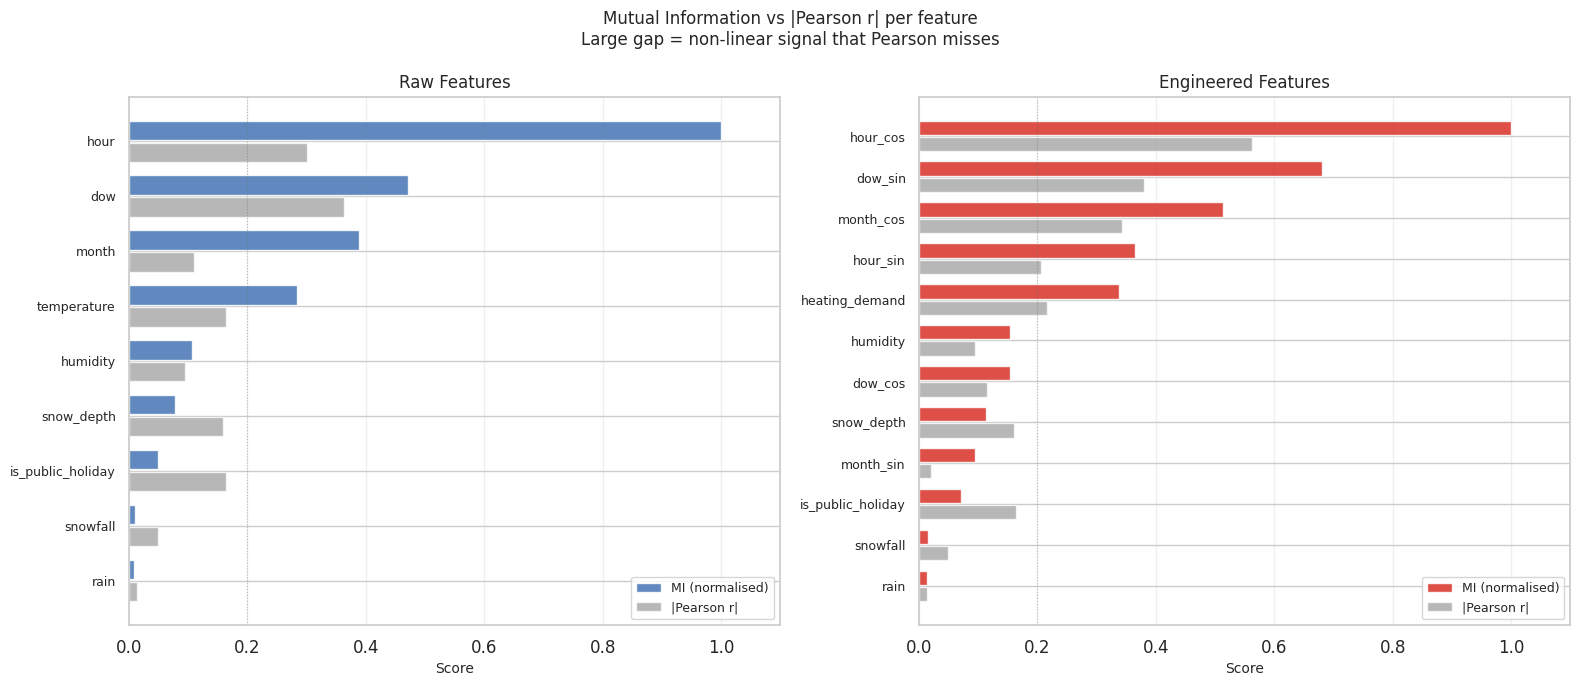

In [8]:
# ── Raw vs Engineered: correlation-with-demand comparison ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, results, title, bar_color in [
    (axes[0], results_raw, 'Raw Features',        '#4575b4'),
    (axes[1], results_eng, 'Engineered Features', '#d73027'),
]:
    r = results.sort_values('mi_norm')
    y_pos = np.arange(len(r))

    ax.barh(y_pos + 0.2, r['mi_norm'], height=0.35,
            color=bar_color, alpha=0.85, label='MI (normalised)')
    ax.barh(y_pos - 0.2, r['abs_r'],   height=0.35,
            color='#999999', alpha=0.7,  label='|Pearson r|')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(r.index, fontsize=9)
    ax.set_xlabel('Score', fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 1.1)
    ax.axvline(0.2, color='grey', ls=':', lw=0.8, alpha=0.5)
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle(
    'Mutual Information vs |Pearson r| per feature\n'
    'Large gap = non-linear signal that Pearson misses',
    fontsize=12)
plt.tight_layout()
plt.show()


---
## 6 · PCA — Baseline vs Engineered

PCA on standardised features shows how many components are needed for 90% variance. Fewer components = better signal concentration. Comparing baseline vs engineered quantifies the improvement in information density.


Baseline: 8/9 PCs explain ≥90% variance
  PC 1: 0.2105  (cum: 0.2105)
  PC 2: 0.1360  (cum: 0.3465)
  PC 3: 0.1136  (cum: 0.4602)
  PC 4: 0.1117  (cum: 0.5719)
  PC 5: 0.1105  (cum: 0.6824)
  PC 6: 0.1050  (cum: 0.7874)
  PC 7: 0.1026  (cum: 0.8900)
  PC 8: 0.0788  (cum: 0.9688) ← 90%
  PC 9: 0.0312  (cum: 1.0000)

Engineered: 9/12 PCs explain ≥90% variance
  PC 1: 0.2089  (cum: 0.2089)
  PC 2: 0.1104  (cum: 0.3192)
  PC 3: 0.0888  (cum: 0.4080)
  PC 4: 0.0855  (cum: 0.4935)
  PC 5: 0.0839  (cum: 0.5774)
  PC 6: 0.0834  (cum: 0.6608)
  PC 7: 0.0822  (cum: 0.7430)
  PC 8: 0.0810  (cum: 0.8240)
  PC 9: 0.0784  (cum: 0.9024) ← 90%
  PC10: 0.0598  (cum: 0.9622)
  PC11: 0.0256  (cum: 0.9878)
  PC12: 0.0122  (cum: 1.0000)


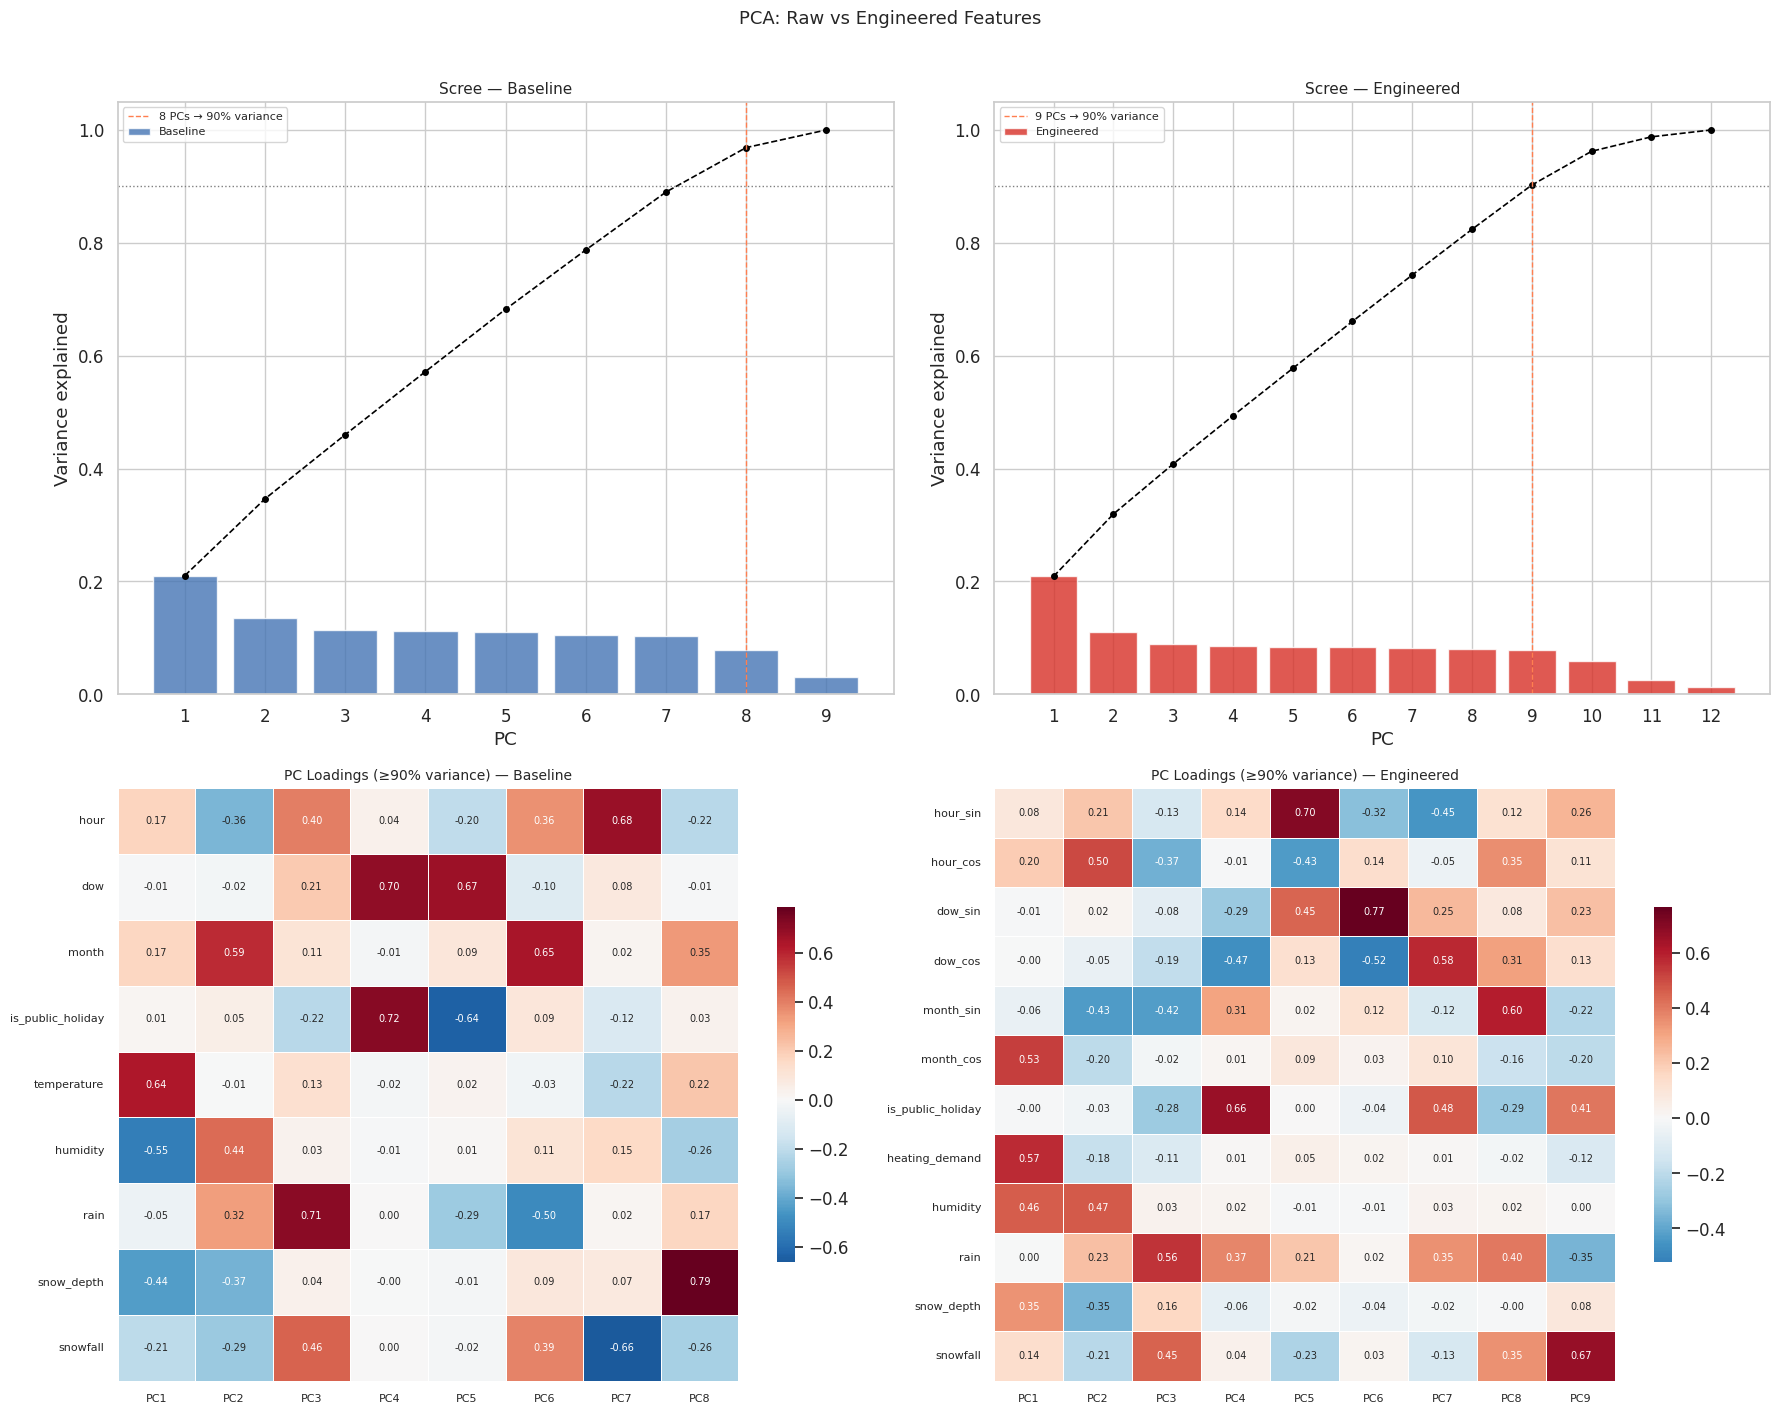

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def run_pca(features, label, color, ax_scree, ax_load):
    X = eval_df[features].values
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)
    pca = PCA()
    pca.fit(X_sc)
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    # Scree
    n = len(features)
    ax_scree.bar(range(1, n+1), pca.explained_variance_ratio_,
                 color=color, alpha=0.8, edgecolor='white', label=label)
    ax_scree.plot(range(1, n+1), cumvar, 'o--', color='black', ms=4, lw=1.2)
    ax_scree.axhline(0.90, ls=':', color='grey', lw=1)
    n90 = int(np.searchsorted(cumvar, 0.90)) + 1
    ax_scree.axvline(n90, ls='--', color='coral', lw=1,
                     label=f'{n90} PCs → 90% variance')
    ax_scree.set_title(f'Scree — {label}', fontsize=11)
    ax_scree.set_xlabel('PC')
    ax_scree.set_ylabel('Variance explained')
    ax_scree.legend(fontsize=8)
    ax_scree.set_xticks(range(1, n+1))

    # Loadings heatmap for PCs up to 90%
    loadings = pd.DataFrame(
        pca.components_[:n90].T,
        columns=[f'PC{i+1}' for i in range(n90)],
        index=features
    )
    sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                linewidths=0.4, ax=ax_load, annot_kws={'size': 7},
                cbar_kws={'shrink': 0.6})
    ax_load.set_title(f'PC Loadings (≥90% variance) — {label}', fontsize=10)
    ax_load.tick_params(axis='x', labelsize=8)
    ax_load.tick_params(axis='y', labelsize=8)

    print(f'\n{label}: {n90}/{n} PCs explain ≥90% variance')
    for i, (v, c) in enumerate(zip(pca.explained_variance_ratio_, cumvar)):
        marker = ' ← 90%' if i+1 == n90 else ''
        print(f'  PC{i+1:>2}: {v:.4f}  (cum: {c:.4f}){marker}')
    return pca

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

pca_raw = run_pca(BASELINE_FEATURES, 'Baseline',        '#4575b4', axes[0][0], axes[1][0])
pca_eng = run_pca(ENG_FEATURES, 'Engineered', '#d73027', axes[0][1], axes[1][1])

plt.suptitle('PCA: Raw vs Engineered Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ── Baseline feature set (used in all subsequent models) ─────────────────
SUBSET_F = [
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'is_public_holiday',
    'heating_demand',
    'humidity', 'rain', 'snow_depth', 'snowfall',
]

# Verify no pairs above |r| > 0.7 (except known month_cos × heating_demand at 0.81)
f_corr = eval_df[SUBSET_F].corr()
print('Pairs with |r| > 0.7 in baseline feature set:')
found = False
for i in range(len(SUBSET_F)):
    for j in range(i+1, len(SUBSET_F)):
        r = float(f_corr.iloc[i, j])  # type: ignore[arg-type]
        if abs(r) > 0.7:
            print(f'  {SUBSET_F[i]:20s} × {SUBSET_F[j]:20s}  r = {r:.3f}')
            found = True
if not found:
    print('  None.')
print(f'\nBaseline: {len(SUBSET_F)} features')

Pairs with |r| > 0.7 in baseline feature set:
  month_cos            × heating_demand        r = 0.809

Baseline: 12 features


---
## 7 · Demand Lag Features

Demand is strongly autocorrelated — yesterday's pattern is the best single predictor of today's. For a TFT with a 48-hour encoder window decoding 24 hours ahead, the model already *sees* recent demand through its encoder. But computing explicit lag features gives a linear baseline something to work with, and tells us how much signal lives in recent history alone.

**What's valid (no leakage):** any demand value from strictly before time *t*.
- `lag_24h` = demand at *t*−24 ✓
- `lag_48h` = demand at *t*−48 ✓
- `delta_lag` = lag_24h − lag_48h (rate of change, 24h → 48h ago) ✓
- `roll_mean_48h` = mean of demand over [*t*−48, *t*−1] ✓
- `roll_std_48h` = std of demand over [*t*−48, *t*−1] ✓

**What's NOT valid:** any expression containing demand at time *t* itself — `delta_24h = demand(t) − lag_24h` in complete_data.py is a direct target leak.

All lag values are normalised by 10,000 (approximate MW scale) for model stability.

In [ ]:
# ── Build working dataframe from loaded data ─────────────────────────────
work = df.copy()
work['hour']  = work['timestamp'].dt.hour
work['dow']   = work['timestamp'].dt.dayofweek
work['month'] = work['timestamp'].dt.month
work['year']  = work['timestamp'].dt.year
work['season']= work['month'].map({12:'Winter',1:'Winter',2:'Winter',
                                    3:'Spring', 4:'Spring', 5:'Spring',
                                    6:'Summer', 7:'Summer', 8:'Summer',
                                    9:'Autumn',10:'Autumn',11:'Autumn'})

SCALE = 10_000

# ── Compute lags on the full timeline (shift is inherently causal) ────────
work['lag_24h']      = work['actual_demand'].shift(24)
work['lag_48h']      = work['actual_demand'].shift(48)

# Rate of change between the two lag windows (both historical — no leakage)
work['delta_lag']    = work['lag_24h'] - work['lag_48h']

# Rolling stats over the 48h window immediately before t (shift(1) = exclude t)
work['roll_mean_48h']= work['actual_demand'].shift(1).rolling(48, min_periods=12).mean()
work['roll_std_48h'] = work['actual_demand'].shift(1).rolling(48, min_periods=12).std()

# Normalise
work['lag_24h_norm']       = work['lag_24h']       / SCALE
work['lag_48h_norm']       = work['lag_48h']       / SCALE
work['delta_lag_norm']     = work['delta_lag']      / SCALE
work['roll_mean_48h_norm'] = work['roll_mean_48h']  / SCALE
work['roll_std_48h_norm']  = work['roll_std_48h']   / SCALE

# Same-hour last week (168h) — addresses weekday/weekend pollution in lag_24h.
# lag_24h on a Monday 9am gives Sunday 9am (weekend pattern).
# lag_168h gives last Monday 9am — same day-type, much cleaner signal.
work['lag_168h']         = work['actual_demand'].shift(168)
work['lag_168h_norm']    = work['lag_168h'] / SCALE

# Temperature trend — was it getting colder or warmer in the last 24h?
work['temp_lag_24h']     = work['temperature'].shift(24)
work['temp_delta_24h']   = work['temperature'] - work['temp_lag_24h']  # +ve = warming

LAG_FEATURES = [
    'lag_24h_norm',
    'lag_48h_norm',
    'lag_168h_norm',       # same day-type last week — fixes weekday/weekend pollution
    'delta_lag_norm',
    'roll_mean_48h_norm',
    'roll_std_48h_norm',
]

print('Lag feature sample (first valid row ~row 49):')
print(work[['timestamp','actual_demand'] + LAG_FEATURES].dropna().head(3).to_string())
print(f'\nNull counts: {work[LAG_FEATURES].isnull().sum().to_dict()}')

Lag feature sample (first valid row ~row 49):
              timestamp  actual_demand  lag_24h_norm  lag_48h_norm  lag_168h_norm  delta_lag_norm  roll_mean_48h_norm  roll_std_48h_norm
168 2019-01-08 00:00:00      54874.945      4.737931      4.715661       4.372176        0.022270            5.751418           1.087025
169 2019-01-08 01:00:00      53055.995      4.574091      4.503836       4.206879        0.070256            5.767498           1.077040
170 2019-01-08 02:00:00      52159.625      4.524809      4.368649       4.050798        0.156160            5.784201           1.063153

Null counts: {'lag_24h_norm': 24, 'lag_48h_norm': 48, 'lag_168h_norm': 168, 'delta_lag_norm': 48, 'roll_mean_48h_norm': 12, 'roll_std_48h_norm': 12}


Lag feature correlation with demand:


,pearson_r,abs_r,mi_norm
lag_168h_norm,0.914,0.914,1.000
lag_24h_norm,0.802,0.802,0.724
lag_48h_norm,0.601,0.601,0.332
roll_mean_48h_norm,0.519,0.519,0.225
delta_lag_norm,0.319,0.319,0.106
roll_std_48h_norm,0.295,0.295,0.061


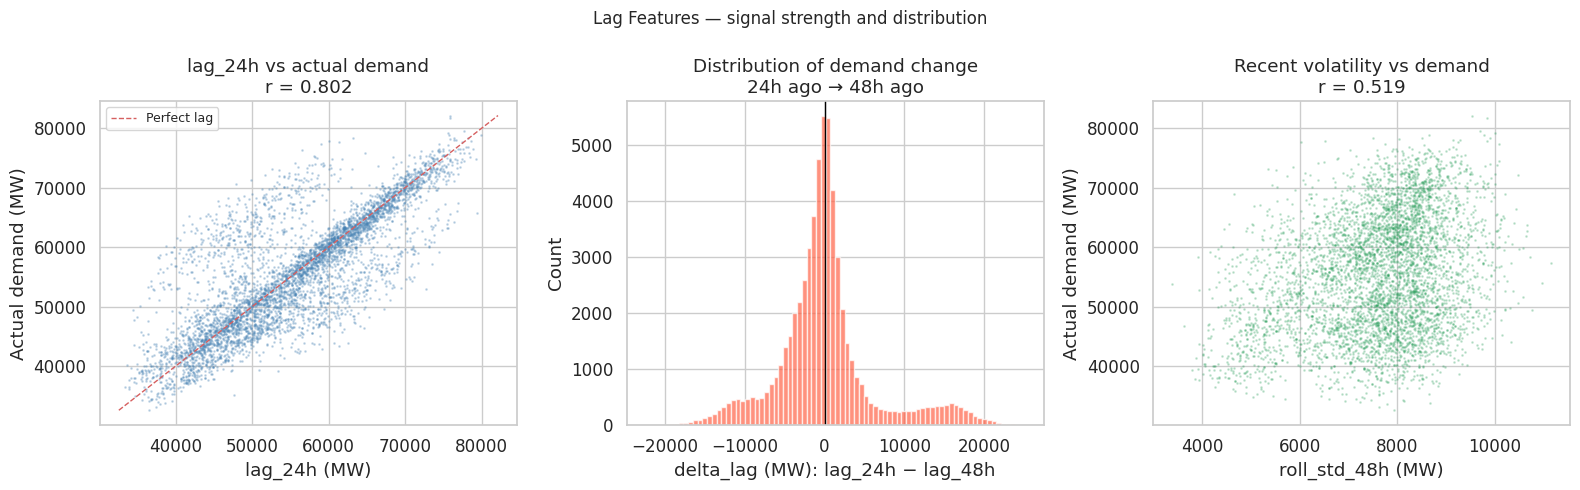

In [ ]:
# ── Correlation and MI of lag features with demand ───────────────────────
lag_eval = work[LAG_FEATURES + ['actual_demand']].dropna().reset_index(drop=True)
y_lag = lag_eval['actual_demand'].to_numpy()

pearson_lag = np.array([float(lag_eval[f].corr(lag_eval['actual_demand'])) for f in LAG_FEATURES])
mi_lag = mutual_info_regression(
    lag_eval[LAG_FEATURES].to_numpy(), y_lag, n_neighbors=10, random_state=42)
mi_lag_norm = mi_lag / mi_lag.max()

results_lag = pd.DataFrame({
    'pearson_r': pearson_lag,
    'abs_r':     np.abs(pearson_lag),
    'mi_norm':   mi_lag_norm,
}, index=LAG_FEATURES).sort_values('mi_norm', ascending=False)

print('Lag feature correlation with demand:')
display(results_lag.round(3))

# ── Side-by-side: lag_24h scatter and delta_lag distribution ─────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter: lag_24h vs actual demand
sample = lag_eval.sample(min(5000, len(lag_eval)), random_state=42)
axes[0].scatter(sample['lag_24h_norm'] * SCALE, sample['actual_demand'],
                s=1, alpha=0.25, color='steelblue')
lims = [sample['actual_demand'].min(), sample['actual_demand'].max()]
axes[0].plot(lims, lims, 'r--', lw=1, label='Perfect lag')
axes[0].set_xlabel('lag_24h (MW)')
axes[0].set_ylabel('Actual demand (MW)')
axes[0].set_title(f'lag_24h vs actual demand\nr = {pearson_lag[0]:.3f}')
axes[0].legend(fontsize=9)

# Delta lag distribution
axes[1].hist(lag_eval['delta_lag_norm'] * SCALE, bins=80,
             color='tomato', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('delta_lag (MW): lag_24h − lag_48h')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of demand change\n24h ago → 48h ago')

# Roll_std_48h vs actual demand — measures recent volatility
axes[2].scatter(sample['roll_std_48h_norm'] * SCALE, sample['actual_demand'],
                s=1, alpha=0.2, color='#1a9850')
axes[2].set_xlabel('roll_std_48h (MW)')
axes[2].set_ylabel('Actual demand (MW)')
axes[2].set_title(f'Recent volatility vs demand\nr = {pearson_lag[4]:.3f}')

plt.suptitle('Lag Features — signal strength and distribution', fontsize=12)
plt.tight_layout()
plt.show()

---
## 8 · Interaction Features

The residual bias heatmap shows a systematic over-forecast at weekend mornings and under-forecast at winter weekday peaks. These are multiplicative relationships — the demand response to cold is different on a weekday than a weekend, and the daily peak timing shifts in winter vs summer.

**What each interaction captures:**

| Feature | Signal |
|---|---|
| `heating_demand × hour_cos` | Cold load shifted by time of day — winter morning peak |
| `heating_demand × is_weekend` | Weekend cold response is damped (less commercial load) |
| `dow_sin × heating_demand` | Day-of-week modulates heating response |
| `is_monday_after_weekend` | Monday demand spike after weekend suppression |
| `is_friday_before_weekend` | Friday afternoon ramp-down |
| `temp_delta_24h` | Temperature trend direction — warming vs cooling |

All are computed from values at or before *t*−1 — no leakage.

In [ ]:
# ── Transition flags (from complete_data.py — valid, no leakage) ─────────
hour = work['timestamp'].dt.hour
dow  = work['timestamp'].dt.dayofweek

work['is_weekend']               = (dow >= 5).astype(float)
work['is_monday_after_weekend']  = (dow == 0).astype(float)
work['is_friday_before_weekend'] = ((dow == 4) & (hour >= 12)).astype(float)

# ── Interaction features ──────────────────────────────────────────────────
work['heat_x_hourcos']    = work['heating_demand'] * work['hour_cos']
work['heat_x_weekend']    = work['heating_demand'] * work['is_weekend']
work['dowsin_x_heating']  = work['dow_sin']        * work['heating_demand']

INT_FEATURES = [
    'is_monday_after_weekend',
    'is_friday_before_weekend',
    'temp_delta_24h',
    'heat_x_hourcos',
    'heat_x_weekend',
    'dowsin_x_heating',
]

# ── Quick MI check: do interactions carry signal beyond component parts? ──
int_eval = work[INT_FEATURES + ['actual_demand']].dropna().reset_index(drop=True)
pearson_int = [float(int_eval[f].corr(int_eval['actual_demand'])) for f in INT_FEATURES]
mi_int = mutual_info_regression(
    int_eval[INT_FEATURES].to_numpy(),
    int_eval['actual_demand'].to_numpy(),
    n_neighbors=10, random_state=42)
mi_int_norm = mi_int / mi_int.max()

results_int = pd.DataFrame({
    'pearson_r': pearson_int,
    'abs_r':     np.abs(pearson_int),
    'mi_norm':   mi_int_norm,
}, index=INT_FEATURES).sort_values('mi_norm', ascending=False)

print('Interaction feature signal:')
display(results_int.round(3))

Interaction feature signal:


,pearson_r,abs_r,mi_norm
heat_x_hourcos,-0.408,0.408,1.000
dowsin_x_heating,0.247,0.247,0.483
heat_x_weekend,-0.181,0.181,0.377
is_friday_before_weekend,0.102,0.102,0.042
is_monday_after_weekend,0.074,0.074,0.029
temp_delta_24h,-0.005,0.005,0.026


---
## 9 · Four-Way Comparison: Baseline → Engineered → +Lags → +Lags+Interactions

Walk-forward CV (expanding window, 12-month minimum, monthly folds).
Ridge regression throughout — improvement comes from features, not model complexity.

**Models:**
- **Baseline:** linear hour/dow/month + raw weather (pre-engineering reference)
- **Engineered:** cyclical encodings + heating_demand + weather
- **Engineered + Lags:** adds lag_24h/48h/168h, delta_lag, roll_mean/std_48h
- **Engineered + Lags + Interactions:** adds transition flags + multiplicative interactions


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ensure all features exist on work
work['hour_sin']       = np.sin(2 * np.pi * work['hour']  / 24)
work['hour_cos']       = np.cos(2 * np.pi * work['hour']  / 24)
work['dow_sin']        = np.sin(2 * np.pi * work['dow']   / 7)
work['dow_cos']        = np.cos(2 * np.pi * work['dow']   / 7)
work['month_sin']      = np.sin(2 * np.pi * (work['month'] - 1) / 12)
work['month_cos']      = np.cos(2 * np.pi * (work['month'] - 1) / 12)
work['heating_demand'] = np.maximum(15 - work['temperature'], 0)

# Naive baselines
work['pred_persist_24h']  = work['actual_demand'].shift(24)
work['pred_persist_168h'] = work['actual_demand'].shift(168)
hourly_dow_mean = work.groupby(['hour','dow'])['actual_demand'].mean()
work['pred_hourly_dow']  = work.set_index(['hour','dow']).index.map(hourly_dow_mean.to_dict())
seasonal_mean = work.groupby(['hour','dow','season'])['actual_demand'].mean()
work['pred_seasonal'] = work.apply(
    lambda r: seasonal_mean.get((r['hour'], r['dow'], r['season']), np.nan), axis=1)

RAW_FEATURES_CV  = ['hour','dow','month','is_public_holiday',
                    'temperature','humidity','rain','snow_depth','snowfall']
SUBSET_F         = ['hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos',
                    'is_public_holiday','heating_demand',
                    'humidity','rain','snow_depth','snowfall']
SUBSET_F_LAGS    = SUBSET_F + LAG_FEATURES
SUBSET_F_LAGS_INT= SUBSET_F_LAGS + INT_FEATURES

def compute_metrics(actual, predicted, name):
    mask = ~(np.isnan(actual) | np.isnan(predicted))
    a, p = actual[mask], predicted[mask]
    return {'Model': name,
            'MAE (MW)':  round(np.mean(np.abs(a - p)), 1),
            'RMSE (MW)': round(np.sqrt(np.mean((a-p)**2)), 1),
            'MAPE (%)':  round(np.mean(np.abs((a-p)/a))*100, 3),
            'Bias (MW)': round(np.mean(p - a), 1),
            'n': int(mask.sum())}

months_cv = sorted(work['timestamp'].dt.to_period('M').unique())
MIN_TRAIN = 12

def run_cv(feature_list):
    results = []
    for i in range(MIN_TRAIN, len(months_cv)):
        tp = months_cv[i]
        tr = work['timestamp'].dt.to_period('M') < tp
        te = work['timestamp'].dt.to_period('M') == tp
        tr_d = work[tr][feature_list + ['actual_demand']].dropna()
        te_d = work[te][feature_list + ['actual_demand']].dropna()
        if len(tr_d) < 200 or len(te_d) < 10:
            continue
        sc = StandardScaler()
        Xtr = sc.fit_transform(tr_d[feature_list])
        Xte = sc.transform(te_d[feature_list])
        m = Ridge(alpha=1.0)
        m.fit(Xtr, tr_d['actual_demand'].values)
        p = m.predict(Xte)
        results.append({'period': str(tp), 'year': tp.year, 'month': tp.month,
                        'mae':  mean_absolute_error(te_d['actual_demand'].values, p),
                        'rmse': np.sqrt(mean_squared_error(te_d['actual_demand'].values, p)),
                        'bias': float(np.mean(p - te_d['actual_demand'].values)),
                        'actual': te_d['actual_demand'].values, 'predicted': p})
    return results

print('Running walk-forward CV (4 models)...')
cv_raw  = run_cv(RAW_FEATURES_CV)
cv_f    = run_cv(SUBSET_F)
cv_fl   = run_cv(SUBSET_F_LAGS)
cv_fli  = run_cv(SUBSET_F_LAGS_INT)
print(f'  {len(cv_raw)} monthly folds each.')

def fold_df(cv):
    return pd.DataFrame([{k:v for k,v in r.items() if k not in ('actual','predicted')}
                          for r in cv])

df_raw  = fold_df(cv_raw)
df_f    = fold_df(cv_f)
df_fl   = fold_df(cv_fl)
df_fli  = fold_df(cv_fli)

def cv_metrics(cv, name):
    a = np.concatenate([r['actual']    for r in cv])
    p = np.concatenate([r['predicted'] for r in cv])
    return compute_metrics(a, p, name)

summary = pd.DataFrame([
    compute_metrics(work['actual_demand'].values, work['pred_persist_24h'].values,  'Naive: Persistence-24h'),
    compute_metrics(work['actual_demand'].values, work['pred_persist_168h'].values, 'Naive: Persistence-168h'),
    compute_metrics(work['actual_demand'].values, work['pred_hourly_dow'].values,   'Naive: Hourly-DoW Mean'),
    compute_metrics(work['actual_demand'].values, work['pred_seasonal'].values,     'Naive: Seasonal DoW Mean'),
    cv_metrics(cv_raw, f'Ridge: Baseline ({len(RAW_FEATURES_CV)}f)'),
    cv_metrics(cv_f,   f'Ridge: Engineered ({len(SUBSET_F)}f)'),
    cv_metrics(cv_fl,  f'Ridge: Engineered + Lags ({len(SUBSET_F_LAGS)}f)'),
    cv_metrics(cv_fli, f'Ridge: Engineered + Lags + Int ({len(SUBSET_F_LAGS_INT)}f)'),
]).set_index('Model')

display(summary[['MAE (MW)','RMSE (MW)','MAPE (%)','Bias (MW)','n']])

Running walk-forward CV (4 models)...
  74 monthly folds each.


,MAE (MW),RMSE (MW),MAPE (%),Bias (MW),n
Model,,,,,
Naive: Persistence-24h,4088.7,6172.9,7.526,-5.9,62121
Naive: Persistence-168h,2553.2,4051.6,4.731,-19.9,61977
Naive: Hourly-DoW Mean,4529.1,5642.5,8.396,0.0,62145
Naive: Seasonal DoW Mean,3593.2,4734.2,6.687,-0.0,62145
Ridge: Baseline (9f),6627.2,8149.4,12.656,1453.8,53386
Ridge: Engineered (12f),4592.4,5695.3,8.726,1502.0,53386
Ridge: Engineered + Lags (18f),2313.7,3218.7,4.250,25.0,53386
Ridge: Engineered + Lags + Int (24f),2124.4,2892.7,3.976,52.4,53386


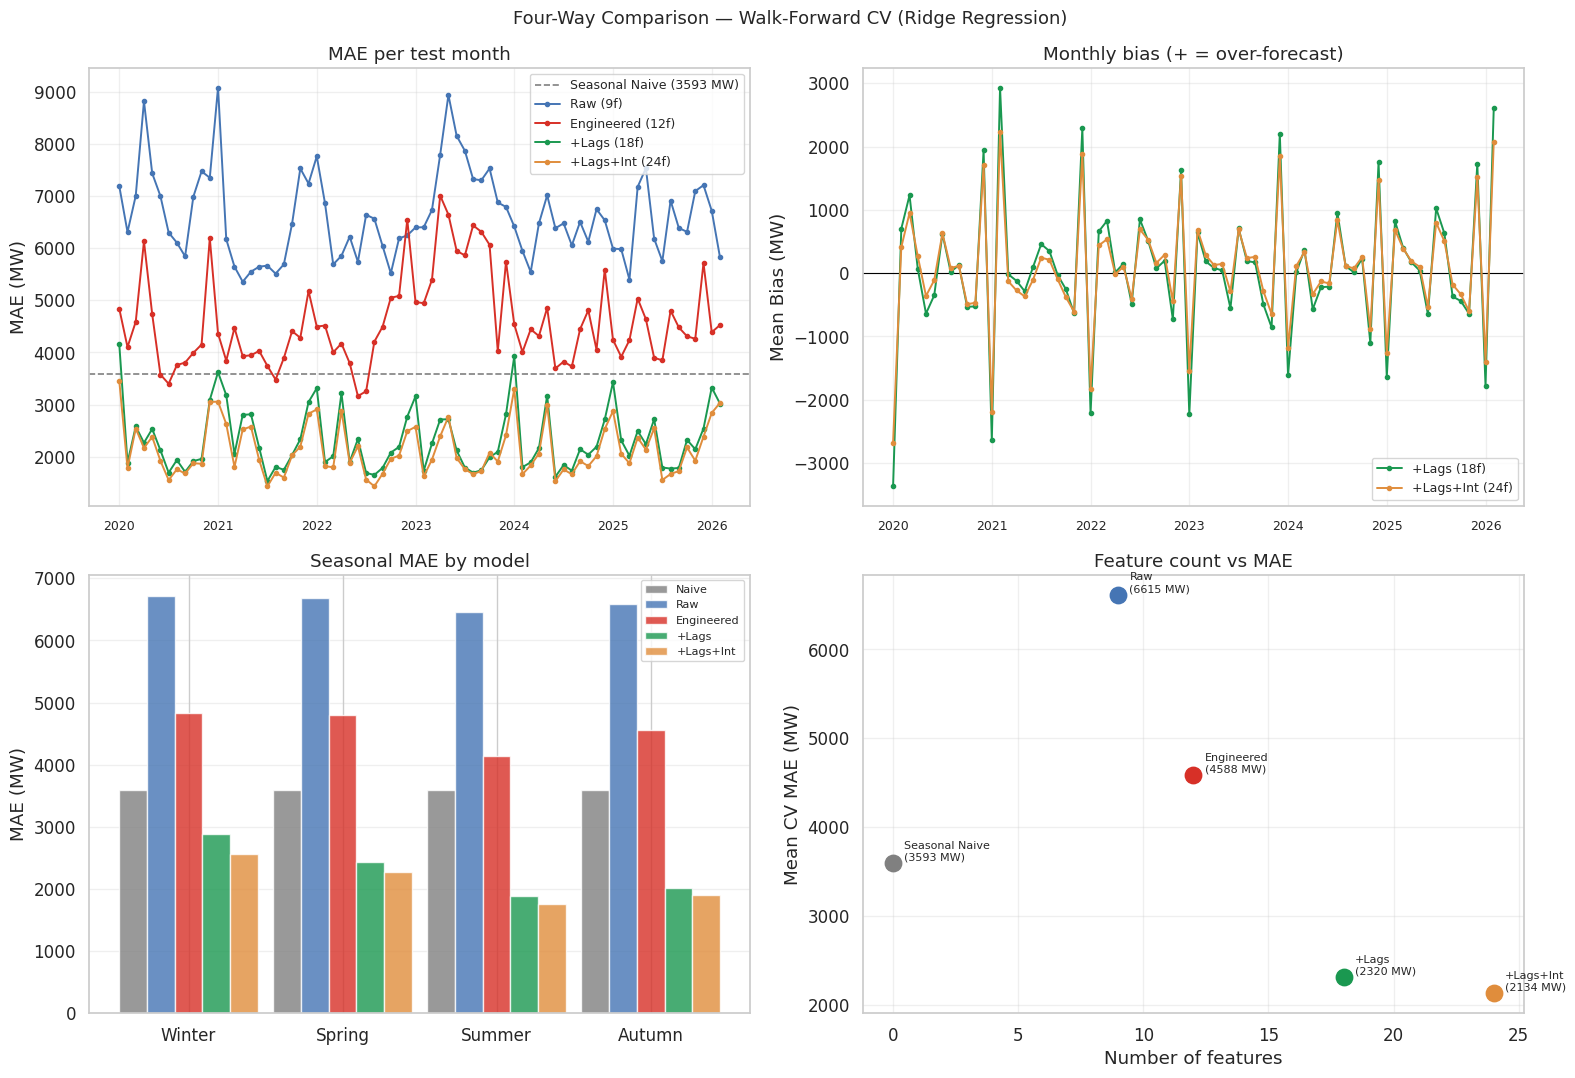

In [15]:
# ── X-axis helper: show Jan of each year only ────────────────────────────
def year_ticks(ax, df_ref):
    """Replace dense month labels with year markers at January of each year."""
    periods = df_ref['period'].tolist()
    tick_pos   = [i for i, p in enumerate(periods) if p.endswith('-01')]
    tick_labels= [p[:4] for p in periods if p.endswith('-01')]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, fontsize=9)

naive_floor = summary.loc['Naive: Seasonal DoW Mean', 'MAE (MW)']
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# (A) MAE over time
ax = axes[0][0]
ax.axhline(naive_floor, ls='--', color='grey', lw=1.2,
           label=f'Seasonal Naive ({naive_floor:.0f} MW)', zorder=1)
for df_, col, label in [
    (df_raw, '#4575b4', f'Raw ({len(RAW_FEATURES_CV)}f)'),
    (df_f,   '#d73027', f'Engineered ({len(SUBSET_F)}f)'),
    (df_fl,  '#1a9850', f'+Lags ({len(SUBSET_F_LAGS)}f)'),
    (df_fli, '#e08d3c', f'+Lags+Int ({len(SUBSET_F_LAGS_INT)}f)'),
]:
    ax.plot(range(len(df_)), df_['mae'], 'o-', color=col, ms=3, lw=1.4, label=label)
year_ticks(ax, df_raw)
ax.set_title('MAE per test month')
ax.set_ylabel('MAE (MW)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# (B) Bias over time — Engineered + Lags vs + Lags + Int
ax = axes[0][1]
ax.axhline(0, color='black', lw=0.8)
for df_, col, label in [
    (df_fl,  '#1a9850', f'+Lags ({len(SUBSET_F_LAGS)}f)'),
    (df_fli, '#e08d3c', f'+Lags+Int ({len(SUBSET_F_LAGS_INT)}f)'),
]:
    ax.plot(range(len(df_)), df_['bias'], 'o-', color=col, ms=3, lw=1.4, label=label)
year_ticks(ax, df_fl)
ax.set_title('Monthly bias (+ = over-forecast)')
ax.set_ylabel('Mean Bias (MW)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# (C) Seasonal MAE
season_order = ['Winter','Spring','Summer','Autumn']
season_map2  = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
                6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'}

def season_mae(cv_list):
    rows = [{'season': season_map2[r['month']], 'mae': r['mae']} for r in cv_list]
    return pd.DataFrame(rows).groupby('season')['mae'].mean()

ax = axes[1][0]
x = np.arange(len(season_order))
w = 0.18
bars = [
    ([summary.loc['Naive: Seasonal DoW Mean','MAE (MW)']]*4, 'grey',    'Naive'),
    ([season_mae(cv_raw).get(s, np.nan) for s in season_order], '#4575b4', 'Raw'),
    ([season_mae(cv_f).get(s, np.nan)   for s in season_order], '#d73027', 'Engineered'),
    ([season_mae(cv_fl).get(s, np.nan)  for s in season_order], '#1a9850', '+Lags'),
    ([season_mae(cv_fli).get(s, np.nan) for s in season_order], '#e08d3c', '+Lags+Int'),
]
for idx, (vals, col, label) in enumerate(bars):
    ax.bar(x + (idx - 2) * w, vals, width=w, color=col, alpha=0.8, label=label)
ax.set_xticks(x); ax.set_xticklabels(season_order)
ax.set_ylabel('MAE (MW)')
ax.set_title('Seasonal MAE by model')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# (D) Feature count vs MAE
ax = axes[1][1]
eff = [
    ('Seasonal Naive',                    0,                       naive_floor,            'grey'),
    (f'Raw',                              len(RAW_FEATURES_CV),   df_raw['mae'].mean(),   '#4575b4'),
    (f'Engineered',                        len(SUBSET_F),          df_f['mae'].mean(),     '#d73027'),
    (f'+Lags',                            len(SUBSET_F_LAGS),     df_fl['mae'].mean(),    '#1a9850'),
    (f'+Lags+Int',                        len(SUBSET_F_LAGS_INT), df_fli['mae'].mean(),   '#e08d3c'),
]
for label, nf, mae, col in eff:
    ax.scatter(nf, mae, color=col, s=140, zorder=3)
    ax.annotate(f'{label}\n({mae:.0f} MW)', (nf, mae),
                textcoords='offset points', xytext=(8, 2), fontsize=8)
ax.set_xlabel('Number of features')
ax.set_ylabel('Mean CV MAE (MW)')
ax.set_title('Feature count vs MAE')
ax.grid(alpha=0.3)

plt.suptitle('Four-Way Comparison — Walk-Forward CV (Ridge Regression)', fontsize=13)
plt.tight_layout()
plt.show()

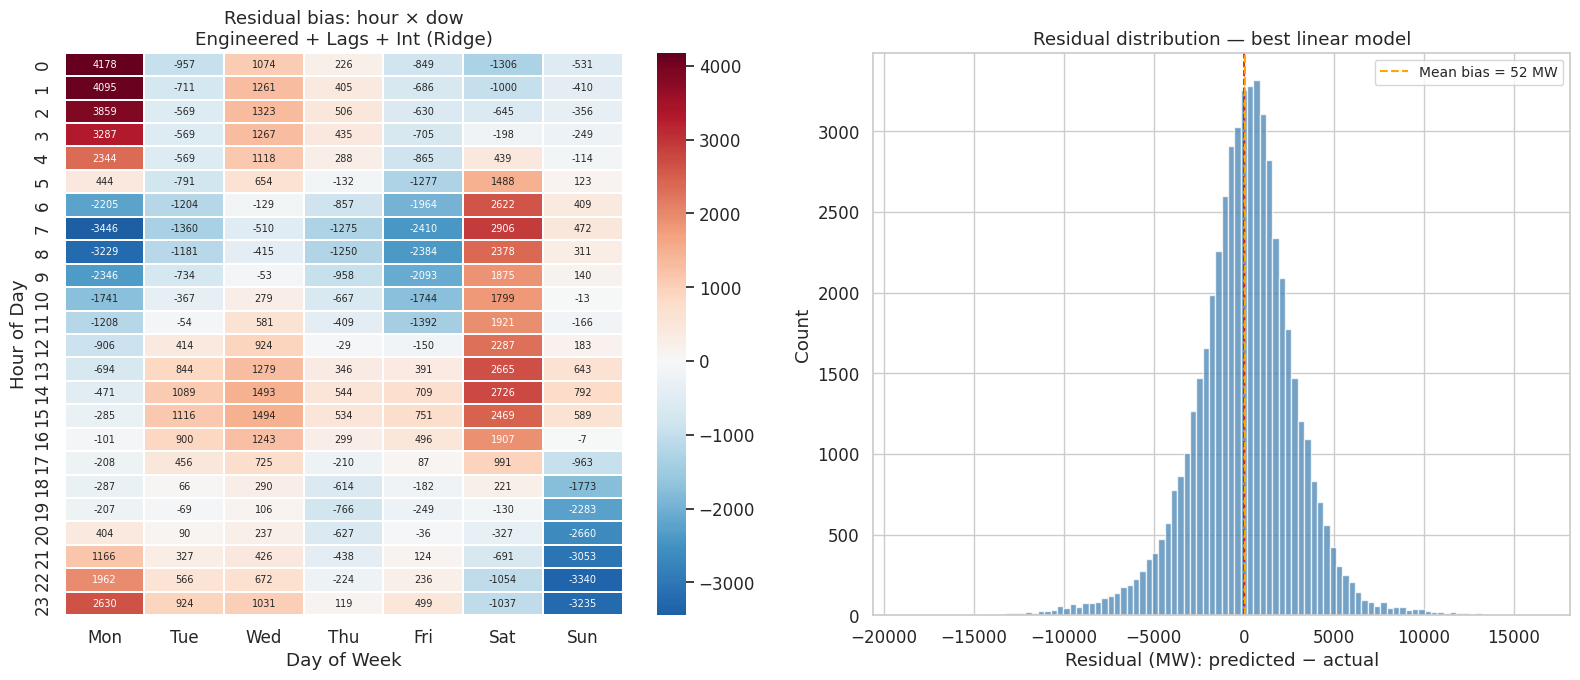

Remaining bias pattern = non-linear multiplicative interactions.
The TFT attention mechanism learns these directly from the encoder sequence.


In [16]:
# ── Residual bias heatmap — best model: Engineered + Lags + Int ─────────
test_periods = set(r['period'] for r in cv_fli)
test_mask    = work['timestamp'].dt.to_period('M').astype(str).isin(test_periods)
test_work    = work[test_mask][SUBSET_F_LAGS_INT + ['actual_demand','hour','dow']].dropna().copy()
all_preds_fli= np.concatenate([r['predicted'] for r in cv_fli])
test_work    = test_work.iloc[:len(all_preds_fli)].copy()
test_work['residual'] = all_preds_fli - test_work['actual_demand'].values

bias_pivot = test_work.groupby(['hour','dow'])['residual'].mean().unstack()
bias_pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(bias_pivot, cmap='RdBu_r', center=0, annot=True, fmt='.0f',
            ax=axes[0], linewidths=0.3, annot_kws={'size': 7})
axes[0].set_title('Residual bias: hour × dow\nEngineered + Lags + Int (Ridge)')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Hour of Day')

axes[1].hist(test_work['residual'], bins=100,
             color='steelblue', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='red', lw=1.2, ls='--')
axes[1].axvline(test_work['residual'].mean(), color='orange', lw=1.5, ls='--',
                label=f'Mean bias = {test_work["residual"].mean():.0f} MW')
axes[1].set_xlabel('Residual (MW): predicted − actual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution — best linear model')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print('Remaining bias pattern = non-linear multiplicative interactions.')
print('The TFT attention mechanism learns these directly from the encoder sequence.')

---
## 10 · Complete Data Feature Set — Leakage-Fixed Comparison

The original `complete_data.py` had 56 features but contained two sources of
data leakage that made its CV results artificially good:

| Leaked feature | Problem | Fix |
|---|---|---|
| `demand_delta_24h = (demand(t) − lag_24h)` | Contains the target at time *t* directly | Replace with `(lag_24h − lag_48h)` — both historical |
| `demand_rolling_std_7d = rolling(168).std()` | Rolling window includes demand(t) itself | Add `.shift(1)` to exclude current row |

After fixing these, we compare the full ~45-feature set against the 24-feature
Engineered + Lags + Int set to check whether the additional complexity earns
anything.


In [17]:
# ── Build complete_data.py features with leakage fixed ───────────────────────
cd = work.copy()
ts    = cd['timestamp']
hour  = ts.dt.hour
dow   = ts.dt.dayofweek
month = ts.dt.month
temp  = cd['temperature']

# Temporal
cd['hour_sin']  = np.sin(2 * np.pi * hour  / 24)
cd['hour_cos']  = np.cos(2 * np.pi * hour  / 24)
cd['dow_sin']   = np.sin(2 * np.pi * dow   / 7)
cd['dow_cos']   = np.cos(2 * np.pi * dow   / 7)
cd['month_sin'] = np.sin(2 * np.pi * (month - 1) / 12)
cd['month_cos'] = np.cos(2 * np.pi * (month - 1) / 12)

for i in range(7):
    cd[f'dow_{i}'] = (dow == i).astype(float)

cd['is_weekend']               = (dow >= 5).astype(float)
cd['is_weekday']               = (dow < 5).astype(float)
cd['is_monday_after_weekend']  = (dow == 0).astype(float)
cd['is_friday_before_weekend'] = ((dow == 4) & (hour >= 12)).astype(float)

cd['is_early_morning'] = ((hour >= 5) & (hour < 8)).astype(float)
cd['is_morning_ramp']  = ((hour >= 6) & (hour < 10)).astype(float)
cd['is_night']         = ((hour >= 22) | (hour < 6)).astype(float)
cd['is_peak_hour']     = ((hour >= 9) & (hour < 20)).astype(float)
cd['is_valley_hour']   = ((hour >= 0) & (hour < 5)).astype(float)
cd['hour_squared']     = (hour ** 2) / (24 ** 2)

cd['day_transition_type'] = 0.0
cd.loc[dow == 6, 'day_transition_type'] = 1.0
cd.loc[dow == 4, 'day_transition_type'] = 2.0

is_summer = (
    ((month > 3) & (month < 10)) |
    ((month == 3) & (ts.dt.day >= 25)) |
    ((month == 10) & (ts.dt.day < 25))
)
cd['daylight_savings_winter'] = (~is_summer).astype(float)
cd['daylight_savings_summer'] = is_summer.astype(float)

# Weather
cd['heating_demand']     = np.maximum(18 - temp, 0)
cd['heating_demand_sq']  = cd['heating_demand'] ** 2
cd['heating_demand_log'] = np.log1p(cd['heating_demand'])
cd['temp_severity']      = np.clip((18 - temp) / 28, 0, 1)
cd['is_cold']            = (temp < 5).astype(float)
cd['monday_cold_multiplier'] = cd['dow_0'] * cd['heating_demand']
cd['temp_lag_24h']       = temp.shift(24)   # causal: shift only

# Demand lags — FIXED: no leakage
demand     = cd['actual_demand']
demand_std = demand.std()
SCALE = 10_000

cd['demand_lag_24h']        = demand.shift(24)
cd['demand_lag_48h']        = demand.shift(48)
cd['demand_lag_168h']       = demand.shift(168)
cd['demand_lag_24h_norm']   = cd['demand_lag_24h']  / SCALE
cd['demand_lag_168h_norm']  = cd['demand_lag_168h'] / SCALE
# FIX 1: was (demand(t) - lag_24h) — contained target. Now (lag_24h - lag_48h).
cd['demand_delta_24h']      = (cd['demand_lag_24h'] - cd['demand_lag_48h']) / SCALE
cd['demand_lag_ratio']      = (
    cd['demand_lag_24h'] / cd['demand_lag_168h'].replace(0, 1)
).clip(0.7, 1.3)
# FIX 2: rolling std — add .shift(1) to exclude demand(t) from the window
cd['demand_rolling_std_7d'] = (
    demand.shift(1).rolling(168, min_periods=24).std().fillna(demand_std) / SCALE
)
cd['lag_24h_was_weekend']   = (dow.shift(1) >= 5).astype(float)
cd['lag_168h_was_weekend']  = cd['is_weekend']
same_type = (cd['lag_24h_was_weekend'] == cd['is_weekend']).astype(float)
cd['lag_reliability']       = np.where(same_type == 1, 1.0, 0.5)
cd['demand_lag_adjusted']   = np.where(
    same_type == 1,
    cd['demand_lag_24h_norm'],
    0.5 * (cd['demand_lag_24h_norm'] + cd['demand_lag_168h_norm'])
)
cd['transition_adjustment'] = (
    cd['is_monday_after_weekend'] * 0.1 - cd['is_friday_before_weekend'] * 0.05
)
cd['demand_lag_24h_sq']     = cd['demand_lag_24h_norm'] ** 2
cd['demand_lag_168h_sq']    = cd['demand_lag_168h_norm'] ** 2
cd['demand_lag_24h_log']    = np.log1p(cd['demand_lag_24h_norm'].clip(lower=0))

# Interactions
cd['peak_lag_interaction']       = cd['is_peak_hour'] * cd['demand_lag_24h_norm']
cd['peak_heating_interaction']   = cd['is_peak_hour'] * cd['heating_demand']
cd['weekend_temp_interaction']   = cd['is_weekend']   * cd['temperature']
cd['heating_hour_cos_product']   = cd['heating_demand'] * cd['hour_cos']
cd['temp_lag_ratio_interaction'] = cd['temperature']  * cd['demand_lag_ratio']
cd['night_temp_interaction']     = cd['is_night']     * cd['temperature']
cd['weekend_transition_temp']    = cd['day_transition_type'] * cd['temperature'] * cd['is_weekend']
cd['dow_sin_temp']               = cd['dow_sin']      * cd['temperature']

CD_FEATURES = [
    'hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos',
    'dow_0','dow_1','dow_2','dow_3','dow_4','dow_5','dow_6',
    'is_weekend','is_weekday','is_public_holiday',
    'is_monday_after_weekend','is_friday_before_weekend',
    'is_early_morning','is_morning_ramp','is_night','is_peak_hour','is_valley_hour','hour_squared',
    'day_transition_type','daylight_savings_winter','daylight_savings_summer',
    'temperature','heating_demand','heating_demand_sq',
    'temp_severity','heating_demand_log','monday_cold_multiplier','is_cold','temp_lag_24h',
    'demand_lag_24h_norm','demand_lag_168h_norm','demand_delta_24h',
    'demand_lag_ratio','lag_reliability','demand_lag_adjusted',
    'transition_adjustment','demand_rolling_std_7d',
    'lag_24h_was_weekend','lag_168h_was_weekend',
    'demand_lag_24h_sq','demand_lag_168h_sq','demand_lag_24h_log',
    'peak_lag_interaction','peak_heating_interaction','weekend_temp_interaction',
    'heating_hour_cos_product','temp_lag_ratio_interaction',
    'night_temp_interaction','weekend_transition_temp','dow_sin_temp',
]

print(f'Complete data features: {len(CD_FEATURES)}')
print('Running walk-forward CV...')
# Temporarily point run_cv at cd dataframe by using a lambda wrapper
def run_cv_on(df_src, feature_list):
    from sklearn.linear_model import Ridge
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    results = []
    for i in range(12, len(months_cv)):
        tp = months_cv[i]
        tr = df_src['timestamp'].dt.to_period('M') < tp
        te = df_src['timestamp'].dt.to_period('M') == tp
        tr_d = df_src[tr][feature_list + ['actual_demand']].dropna()
        te_d = df_src[te][feature_list + ['actual_demand']].dropna()
        if len(tr_d) < 200 or len(te_d) < 10:
            continue
        sc = StandardScaler()
        Xtr = sc.fit_transform(tr_d[feature_list])
        Xte = sc.transform(te_d[feature_list])
        m = Ridge(alpha=1.0)
        m.fit(Xtr, tr_d['actual_demand'].values)
        p = m.predict(Xte)
        results.append({'period': str(tp), 'year': tp.year, 'month': tp.month,
                        'mae':  mean_absolute_error(te_d['actual_demand'].values, p),
                        'rmse': np.sqrt(mean_squared_error(te_d['actual_demand'].values, p)),
                        'bias': float(np.mean(p - te_d['actual_demand'].values)),
                        'actual': te_d['actual_demand'].values, 'predicted': p})
    return results

cv_cd  = run_cv_on(cd, CD_FEATURES)
df_cd  = fold_df(cv_cd)
print(f'  Done. {len(cv_cd)} folds.')

def cv_metrics_q(cv, name):
    a = np.concatenate([r['actual']    for r in cv])
    p = np.concatenate([r['predicted'] for r in cv])
    return compute_metrics(a, p, name)

quick = pd.DataFrame([
    cv_metrics_q(cv_fli, f'Ridge: Engineered + Lags + Int ({len(SUBSET_F_LAGS_INT)}f)  ← chosen'),
    cv_metrics_q(cv_cd,  f'Ridge: Complete Data fixed ({len(CD_FEATURES)}f)'),
]).set_index('Model')
display(quick[['MAE (MW)','RMSE (MW)','MAPE (%)','Bias (MW)']])


Complete data features: 56
Running walk-forward CV...
  Done. 74 folds.


,MAE (MW),RMSE (MW),MAPE (%),Bias (MW)
Model,,,,
Ridge: Engineered + Lags + Int (24f) ← chosen,2124.4,2892.7,3.976,52.4
Ridge: Complete Data fixed (56f),1975.8,2705.6,3.736,44.9


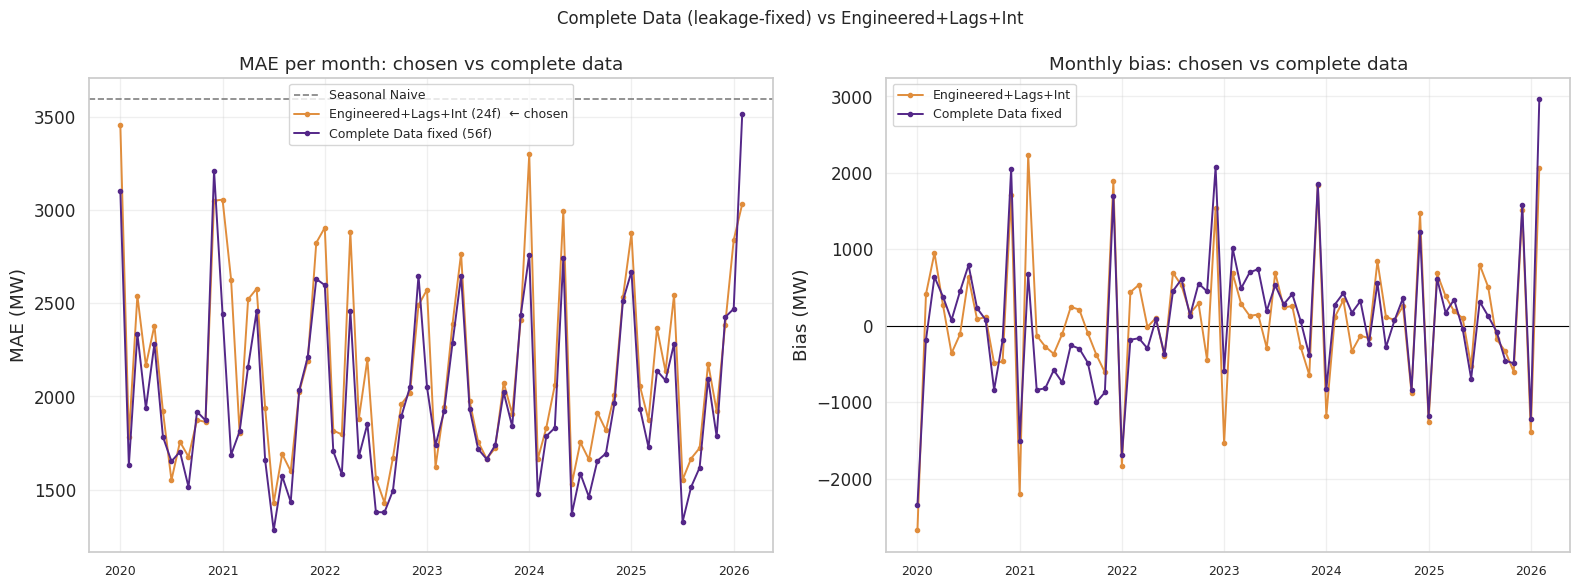

In [18]:
# ── Complete data vs chosen model — visualisation ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.axhline(summary.loc['Naive: Seasonal DoW Mean','MAE (MW)'],
           ls='--', color='grey', lw=1.2, label='Seasonal Naive', zorder=1)
ax.plot(range(len(df_fli)), df_fli['mae'], 'o-', color='#e08d3c', ms=3, lw=1.4,
        label=f'Engineered+Lags+Int ({len(SUBSET_F_LAGS_INT)}f)  ← chosen')
ax.plot(range(len(df_cd)),  df_cd['mae'],  'o-', color='#542788', ms=3, lw=1.4,
        label=f'Complete Data fixed ({len(CD_FEATURES)}f)')
year_ticks(ax, df_fli)
ax.set_title('MAE per month: chosen vs complete data')
ax.set_ylabel('MAE (MW)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.axhline(0, color='black', lw=0.8)
ax.plot(range(len(df_fli)), df_fli['bias'], 'o-', color='#e08d3c', ms=3, lw=1.4,
        label=f'Engineered+Lags+Int')
ax.plot(range(len(df_cd)),  df_cd['bias'],  'o-', color='#542788', ms=3, lw=1.4,
        label=f'Complete Data fixed')
year_ticks(ax, df_fli)
ax.set_title('Monthly bias: chosen vs complete data')
ax.set_ylabel('Bias (MW)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Complete Data (leakage-fixed) vs Engineered+Lags+Int', fontsize=12)
plt.tight_layout()
plt.show()


---
## 10b · Feature Set Decision

Group analysis of the 149 MW gap between 24f and 56f complete data:

| Group | ΔMAE | Interpretation |
|---|---|---|
| A: time-of-day flags | +3.2 MW | Harmful — Ridge artefact |
| **B: DOW dummies + flags** | **−58 MW** | Mixed: dummies are Ridge artefact, but `day_transition_type`, `is_weekend`, and lag day-type flags are genuine |
| **C: lag ratio/context** | **−43 MW** | `lag_24h_was_weekend` and `lag_168h_was_weekend` are genuine — encode day-type of the lag source |
| D: heating transforms | −10 MW | Marginal — monotonic transforms already covered |
| E: extra interactions | −4 MW | Marginal |

Individual tests identified 6 genuine earners (each >−10 MW individually):
`day_transition_type`, `is_weekend`, `lag_24h_was_weekend`, `lag_168h_was_weekend`,
`dow_0–6` block.

**Redundancy problem:** adding `dow_0–6` + `is_weekend` makes `dow_sin/cos` redundant
(dummies fully express the weekly cycle), and `is_weekday` is the exact inverse of
`is_weekend`. These can be dropped to keep the set lean.

**Final test:** de-redundified set removing `dow_sin`, `dow_cos`, `is_weekday`
from the 34f extended set → target ~28–29 features.


In [19]:
# ── De-redundified final set: remove features made redundant by DOW dummies ──
# dow_sin/cos are now fully covered by dow_0–6 (7 dummies span the same space)
# is_weekday is the exact inverse of is_weekend (one is always 1 - the other)

FINAL_SET = [
    # Hourly cycle (kept — dummies don't cover sub-day patterns)
    'hour_sin', 'hour_cos',
    # Weekly cycle — dummies replace cyclical encodings
    'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6',
    # Annual cycle
    'month_sin', 'month_cos',
    # Calendar
    'is_public_holiday',
    'is_monday_after_weekend',
    'is_friday_before_weekend',
    'day_transition_type',       # ← earner: Sun→Mon=1, Fri→Sat=2
    'is_weekend',                 # ← earner: complements dummies for interactions
    # Temperature
    'heating_demand',
    'temp_lag_24h',
    # Weather
    'humidity', 'rain', 'snowfall',
    # Demand lags
    'demand_lag_24h_norm',
    'demand_lag_168h_norm',
    'demand_delta_24h',
    'demand_rolling_std_7d',
    # Lag day-type context  ← earners: encode day-type of the lag source window
    'lag_24h_was_weekend',
    'lag_168h_was_weekend',
    # Interactions
    'heating_hour_cos_product',
    'weekend_temp_interaction',
    'dow_sin_temp',
]

# Verify all features exist on cd
missing = [f for f in FINAL_SET if f not in cd.columns]
if missing:
    print(f'WARNING — missing from cd: {missing}')
else:
    cv_final = run_cv_on(cd, FINAL_SET)
    df_final = fold_df(cv_final)
    final_mae  = df_final['mae'].mean()
    final_bias = df_final['bias'].mean()

    print('=== Feature Set Comparison ===')
    print(f'Naive: Persistence-168h             2553.2 MW  bias =   -19.9 MW')
    print(f'Ridge: Engineered+Lags+Int (24f)    {fold_df(cv_fli)["mae"].mean():.1f} MW  bias = {fold_df(cv_fli)["bias"].mean():+.1f} MW')
    print(f'Ridge: Complete Data fixed (56f)    {fold_df(cv_cd)["mae"].mean():.1f} MW  bias = {fold_df(cv_cd)["bias"].mean():+.1f} MW')
    print(f'Ridge: Final de-redundified ({len(FINAL_SET)}f)  {final_mae:.1f} MW  bias = {final_bias:+.1f} MW')
    print()
    print(f'Gap to complete-data-fixed: {final_mae - fold_df(cv_cd)["mae"].mean():+.1f} MW')
    print()
    print(f'FINAL_SET ({len(FINAL_SET)} features):')
    for i, f in enumerate(FINAL_SET, 1):
        print(f'  {i:>2}. {f}')


=== Feature Set Comparison ===
Naive: Persistence-168h             2553.2 MW  bias =   -19.9 MW
Ridge: Engineered+Lags+Int (24f)    2133.8 MW  bias = +80.9 MW
Ridge: Complete Data fixed (56f)    1992.4 MW  bias = +82.8 MW
Ridge: Final de-redundified (30f)  2016.5 MW  bias = +29.4 MW

Gap to complete-data-fixed: +24.1 MW

FINAL_SET (30 features):
   1. hour_sin
   2. hour_cos
   3. dow_0
   4. dow_1
   5. dow_2
   6. dow_3
   7. dow_4
   8. dow_5
   9. dow_6
  10. month_sin
  11. month_cos
  12. is_public_holiday
  13. is_monday_after_weekend
  14. is_friday_before_weekend
  15. day_transition_type
  16. is_weekend
  17. heating_demand
  18. temp_lag_24h
  19. humidity
  20. rain
  21. snowfall
  22. demand_lag_24h_norm
  23. demand_lag_168h_norm
  24. demand_delta_24h
  25. demand_rolling_std_7d
  26. lag_24h_was_weekend
  27. lag_168h_was_weekend
  28. heating_hour_cos_product
  29. weekend_temp_interaction
  30. dow_sin_temp


---
## 11 · Final Summary

In [ ]:
def cv_m(cv, label):
    a = np.concatenate([r['actual']    for r in cv])
    p = np.concatenate([r['predicted'] for r in cv])
    return compute_metrics(a, p, label)

all_cv = {
    'cv_raw': (cv_raw,  RAW_FEATURES_CV),
    'cv_f':   (cv_f,    SUBSET_F),
    'cv_fl':  (cv_fl,   SUBSET_F_LAGS),
    'cv_fli': (cv_fli,  SUBSET_F_LAGS_INT),
    'cv_cd':  (cv_cd,   CD_FEATURES),
    'cv_final':(cv_final, FINAL_SET),
}

rows = [
    compute_metrics(work['actual_demand'].values, work['pred_persist_24h'].values,  'Naive: Persistence-24h'),
    compute_metrics(work['actual_demand'].values, work['pred_persist_168h'].values, 'Naive: Persistence-168h'),
    compute_metrics(work['actual_demand'].values, work['pred_seasonal'].values,     'Naive: Seasonal DoW Mean'),
]
labels = [
    'Ridge: Baseline',
    'Ridge: Engineered',
    'Ridge: Engineered + Lags',
    'Ridge: Engineered + Lags + Int',
    'Ridge: Complete Data (fixed)',
    'Ridge: Final set',
]
for (name, (cv, feats)), label in zip(all_cv.items(), labels):
    rows.append(cv_m(cv, f'{label} ({len(feats)}f)'))

summary_final = pd.DataFrame(rows).set_index('Model')
display(summary_final[['MAE (MW)', 'RMSE (MW)', 'MAPE (%)', 'Bias (MW)']])

naive168    = float(summary_final.loc['Naive: Persistence-168h', 'MAE (MW)'])  # type: ignore[arg-type]
chosen_mae  = float(summary_final.loc[f'Ridge: Final set ({len(FINAL_SET)}f)', 'MAE (MW)'])  # type: ignore[arg-type]
chosen_bias = float(summary_final.loc[f'Ridge: Final set ({len(FINAL_SET)}f)', 'Bias (MW)'])  # type: ignore[arg-type]
print(f'\nFinal set vs Persistence-168h: {naive168:.1f} → {chosen_mae:.1f} MW '
      f'({(naive168 - chosen_mae) / naive168 * 100:.1f}% reduction, bias = {chosen_bias:+.1f} MW)')
print(f'\nFINAL_SET ({len(FINAL_SET)} features) — ready for TFT training:')
for i, f in enumerate(FINAL_SET, 1):
    print(f'  {i:>2}. {f}')

,MAE (MW),RMSE (MW),MAPE (%),Bias (MW)
Model,,,,
Naive: Persistence-24h,4088.7,6172.9,7.526,-5.9
Naive: Persistence-168h,2553.2,4051.6,4.731,-19.9
Naive: Seasonal DoW Mean,3593.2,4734.2,6.687,-0.0
Ridge: Baseline (9f),6627.2,8149.4,12.656,1453.8
Ridge: Engineered (12f),4592.4,5695.3,8.726,1502.0
Ridge: Engineered + Lags (18f),2313.7,3218.7,4.250,25.0
Ridge: Engineered + Lags + Int (24f),2124.4,2892.7,3.976,52.4
Ridge: Complete Data (fixed) (56f),1975.8,2705.6,3.736,44.9
Ridge: Final set (30f),2001.4,2766.3,3.781,-5.7



Final set vs Persistence-168h: 2553.2 → 2001.4 MW (21.6% reduction, bias = -5.7 MW)

FINAL_SET (30 features) — ready for TFT training:
   1. hour_sin
   2. hour_cos
   3. dow_0
   4. dow_1
   5. dow_2
   6. dow_3
   7. dow_4
   8. dow_5
   9. dow_6
  10. month_sin
  11. month_cos
  12. is_public_holiday
  13. is_monday_after_weekend
  14. is_friday_before_weekend
  15. day_transition_type
  16. is_weekend
  17. heating_demand
  18. temp_lag_24h
  19. humidity
  20. rain
  21. snowfall
  22. demand_lag_24h_norm
  23. demand_lag_168h_norm
  24. demand_delta_24h
  25. demand_rolling_std_7d
  26. lag_24h_was_weekend
  27. lag_168h_was_weekend
  28. heating_hour_cos_product
  29. weekend_temp_interaction
  30. dow_sin_temp
